In [1]:
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
from mcmc import BayesianGammaRegression, BayesianLinearRegression, BayesianPoissonRegression
from mcmc import BayesianLogisticRegression, CallOptionPrice, BayesianNeuralNetwork1Hidden, BayesianNeuralNetwork1Hidden_MALA

# **Call Option Price**

In [4]:
s_0 = 100.0
r = 0.07
sigma = 0.5
k =105.0
t = 1
call_option = CallOptionPrice(s_0, r, sigma, k, t)


In [5]:
_, _, _, x_n = call_option.compute_price_mh(n=6000, n_chains=3, burn_in=2000)

----- Metropolis-Hastings -----
Precio  : 20.6006507874
Precio estimado : 20.6006469727
Error: 0.0000038147
Varianza: 0.0000000000


In [6]:
_, _, _ = call_option.compute_price_mc(n=1000000)

----- Monte Carlo -----
Precio  : 20.6006507874
Precio estimado : 20.6721878052
Error: 0.0715370178
Varianza: 0.0016416521


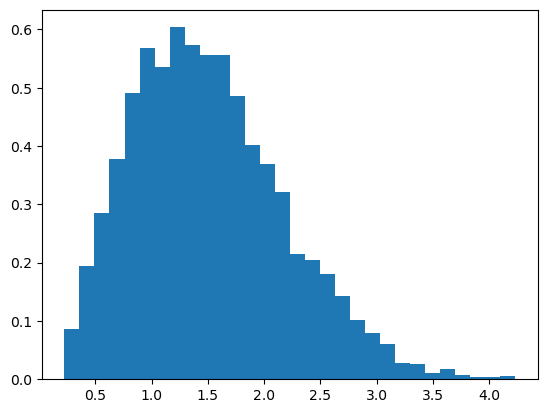

In [7]:
plt.hist(x_n, bins=30, density=True)
plt.show()

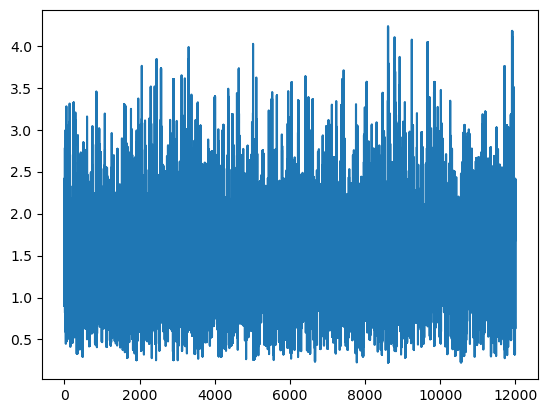

In [8]:
plt.plot(x_n)
plt.show()

# **Regresión Lineal Bayesiana**

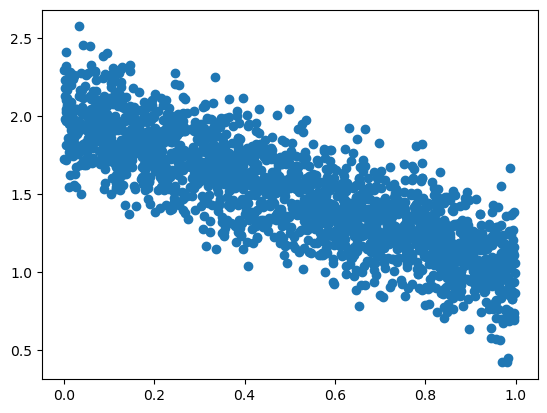

In [3]:
n = 2000
X = torch.rand(n)
X = torch.stack((torch.ones_like(X),X), dim=1)
beta_real = torch.Tensor([2.0,-1.0])
sigma = 0.2
y = X @ beta_real.T + sigma*(torch.randn(n))
plt.scatter(X[:,1],y)
plt.show()

In [5]:
bay_lr = BayesianLinearRegression(num_samples=3000, burn_in=1000, num_chains=3, step_size=0.1, device="cpu")

In [6]:
bay_lr.fit(X, y)

In [7]:
bay_lr.summary()


Posterior Summary

beta:
mean = tensor([ 2.0155, -1.0100])
std  = tensor([0.0095, 0.0157])

log_sigma:
mean = -1.6205869913101196
std  = 0.012009941041469574


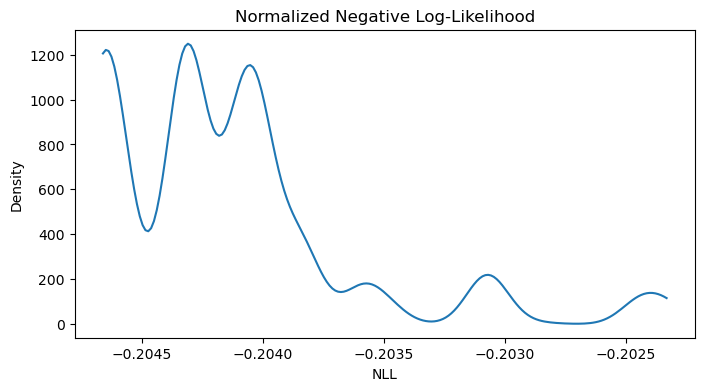

In [8]:
bay_lr.plot_nll_density(X, y)

In [9]:
bay_lr.summary_metrics(X, y)

,mean,std,median,5%,95%,plugin
NNLL,-0.204138,0.000516,-0.204317,-0.204659,-0.203057,-0.204669
MSE,0.038912,0.000037,0.038905,0.038882,0.038996,0.038882
MAE,0.156673,0.000069,0.156653,0.156614,0.156842,0.156617


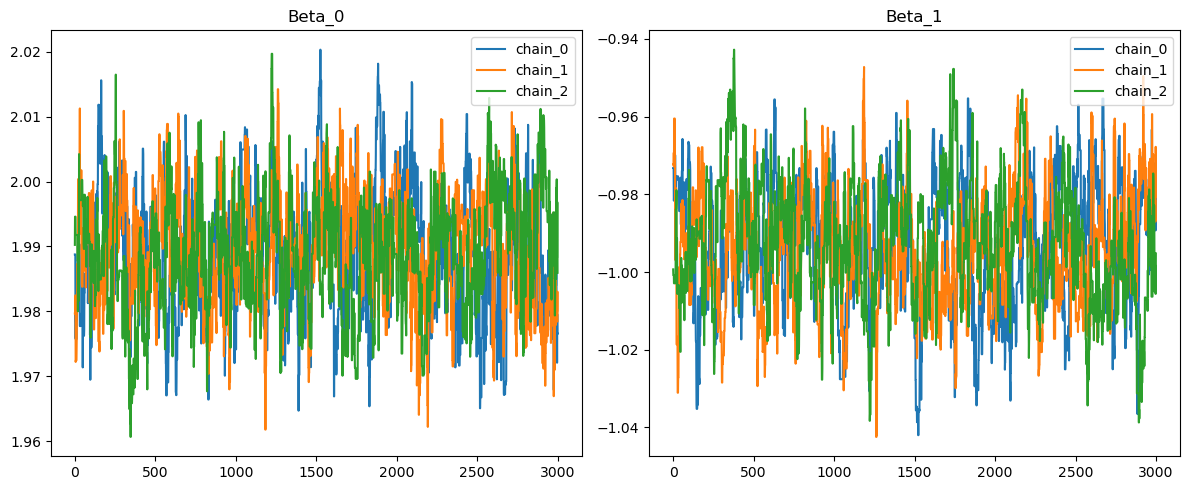

In [8]:
bay_lr.plot_beta_traces(figsize=(12, 5), layout=(1, 2))

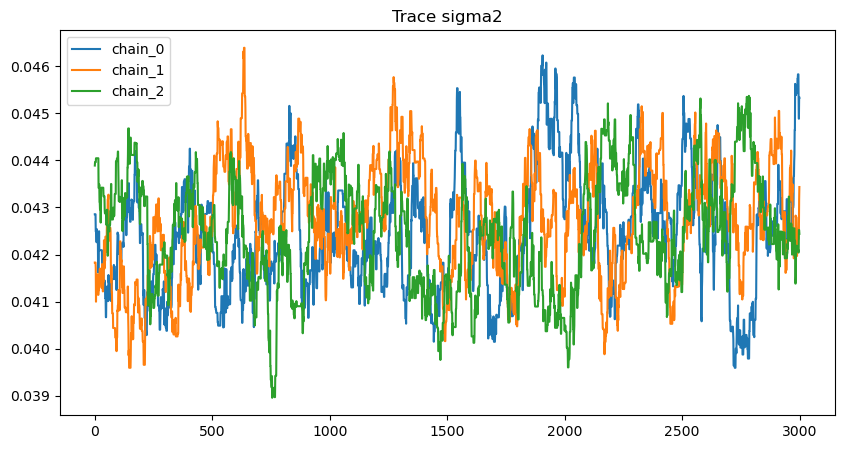

In [9]:
bay_lr.plot_sigma2_traces(figsize=(10, 5))

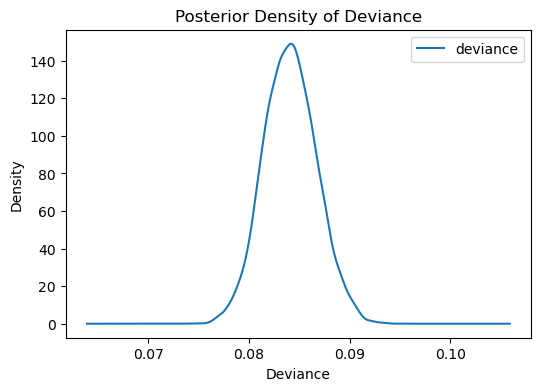

(tensor(0.0791), tensor(0.0894))


In [10]:
bay_lr.plot_deviance_density(X, y)
print(bay_lr.deviance_ci(X, y))

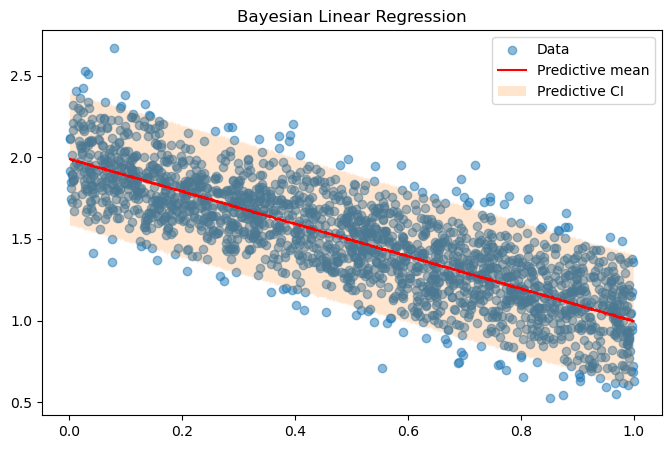

In [11]:
idx = torch.argsort(X[:,1])

X_sorted = X[idx]
y_sorted = y[idx]
# --- Predicciones ---
y_samples = bay_lr.predict_samples(X_sorted)

# Media predictiva
y_mean = y_samples.mean(dim=(0, 1))

# Intervalo predictivo (con ruido)
y_flat = y_samples.reshape(-1, y_samples.shape[-1])
lower = torch.quantile(y_flat, 0.025, dim=0)
upper = torch.quantile(y_flat, 0.975, dim=0)


# --- Plot ---
plt.figure(figsize=(8,5))

# datos reales
plt.scatter(X_sorted[:,1], y_sorted, alpha=0.5, label='Data')

# media
plt.plot(X_sorted[:,1], y_mean, label='Predictive mean', color='red')


# banda predictiva
plt.fill_between(
    X_sorted[:,1],
    lower,
    upper,
    alpha=0.2,
    label='Predictive CI'
)

plt.legend()
plt.title("Bayesian Linear Regression")
plt.show()

# **Regresión Logistica**

In [10]:
n = 2000
d = 3
X = torch.randn(n, d)
X = torch.cat((torch.ones((n, 1)), X), dim=1)
beta_true = torch.tensor([2.0, -1.0, 0.0, 2.4])

logits = X @ beta_true

probs = torch.sigmoid(logits)

y = torch.bernoulli(probs)

In [12]:
logit_model = BayesianLogisticRegression(n_iter=5000, burn_in=2000, step_size=0.05,n_chains=4)
logit_model.fit(X, y)

AttributeError: 'BayesianLogisticRegression' object has no attribute 'd'

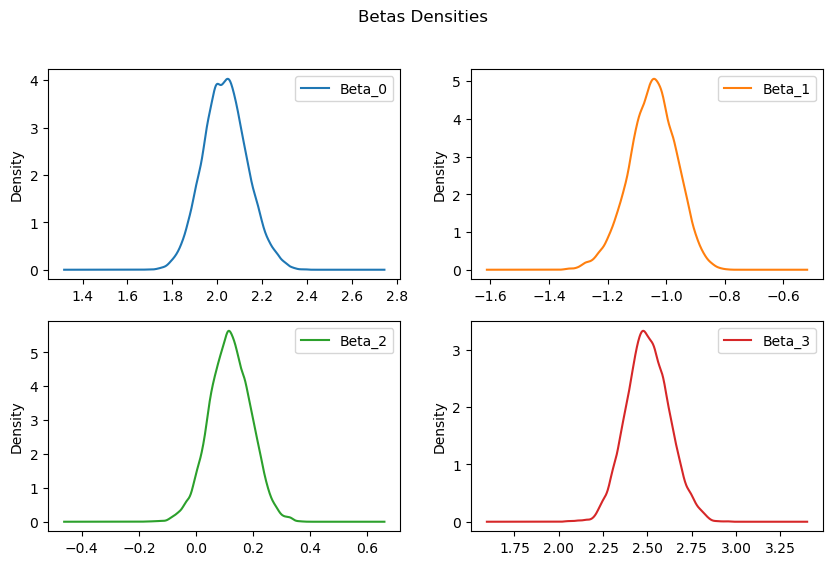

In [14]:
logit_model.plot_betas_densities(figsize=(10, 6), layout=(2, 2))

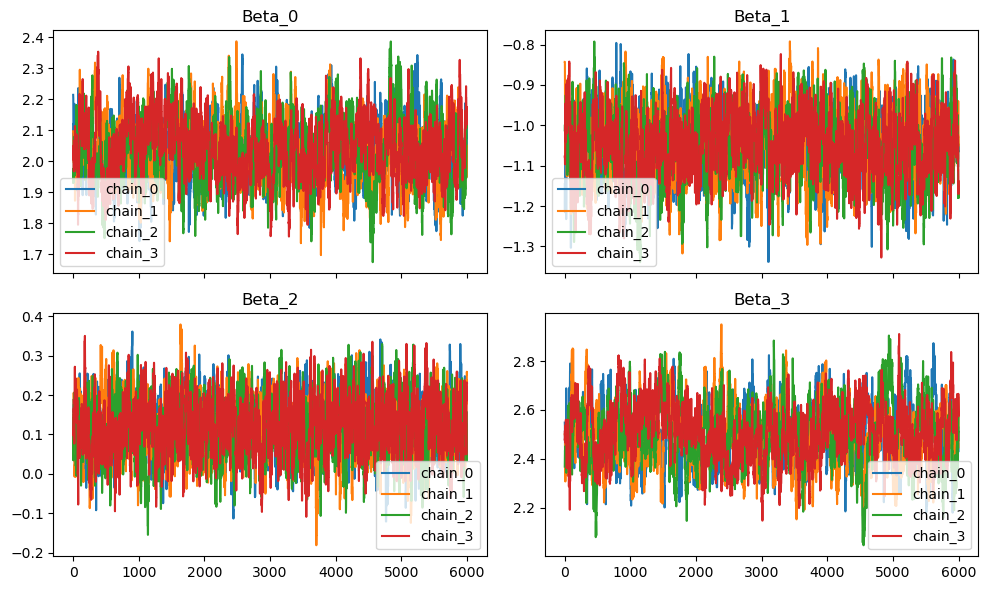

In [15]:
logit_model.plot_beta_traces(figsize=(10, 6), layout=(2, 2))

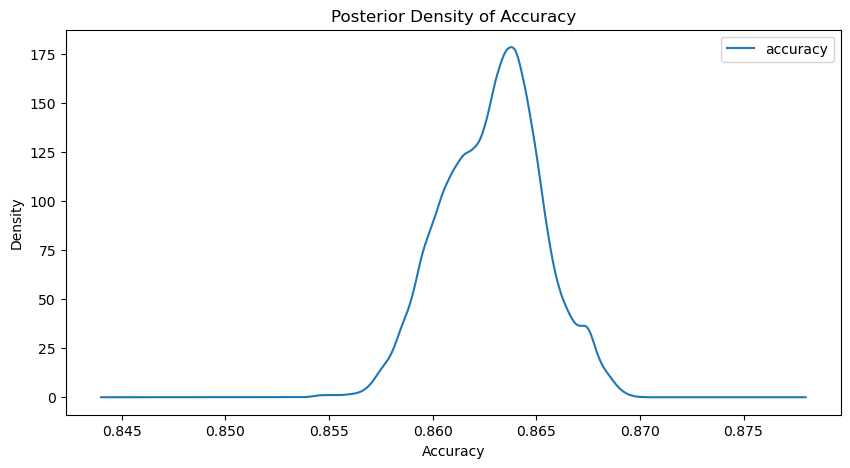

In [16]:
logit_model.plot_accuracy_density(X, y, figsize=(10, 5))

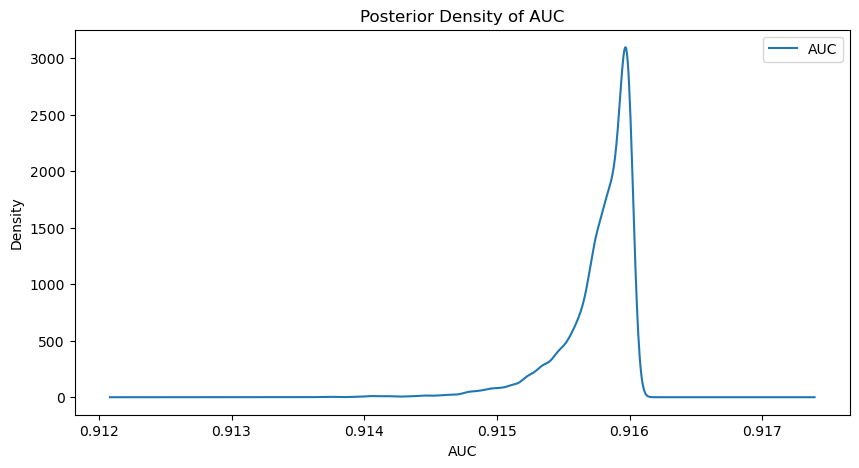

In [17]:
logit_model.plot_auc_density(X, y, figsize=(10, 5))

In [18]:
logit_model.accuracy_ci(X, y)

(tensor(0.8585), tensor(0.8675))

# **Regresión Poisson**

In [20]:
n = 10000
d = 5
X = torch.randn(n, d)
beta_true = torch.tensor([0.5, 0.0, 0.8, 0.6, 0.0])
z = X @ beta_true
rate = torch.exp(z)
y = torch.poisson(rate)

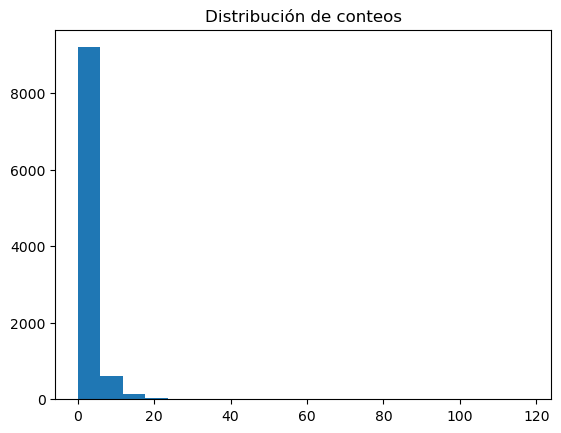

In [21]:
plt.hist(y.numpy(), bins=20)
plt.title("Distribución de conteos")
plt.show()

In [22]:
model = BayesianPoissonRegression(X, y)

model.fit(n_iter=4000, burn_in=1000, n_chains=4, step_size=0.01)

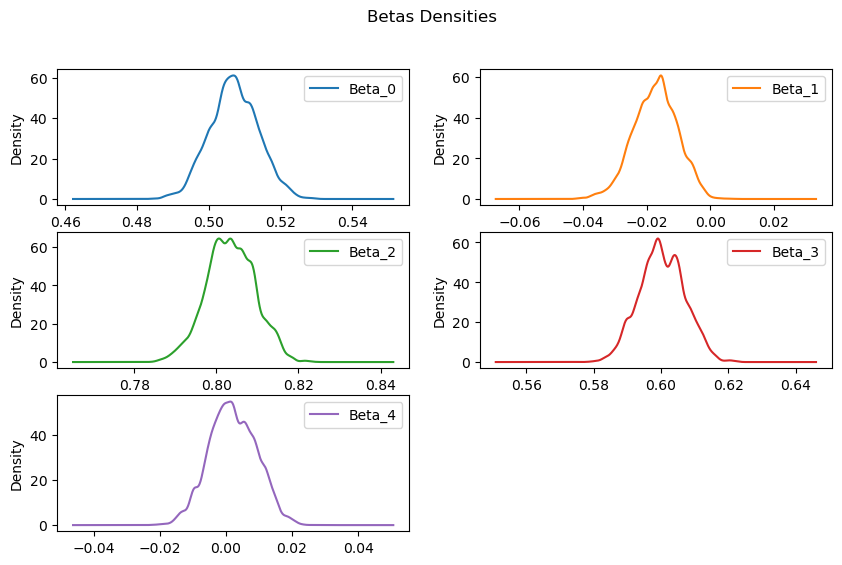

In [23]:
model.plot_betas_densities(figsize=(10, 6), layout=(3, 2))

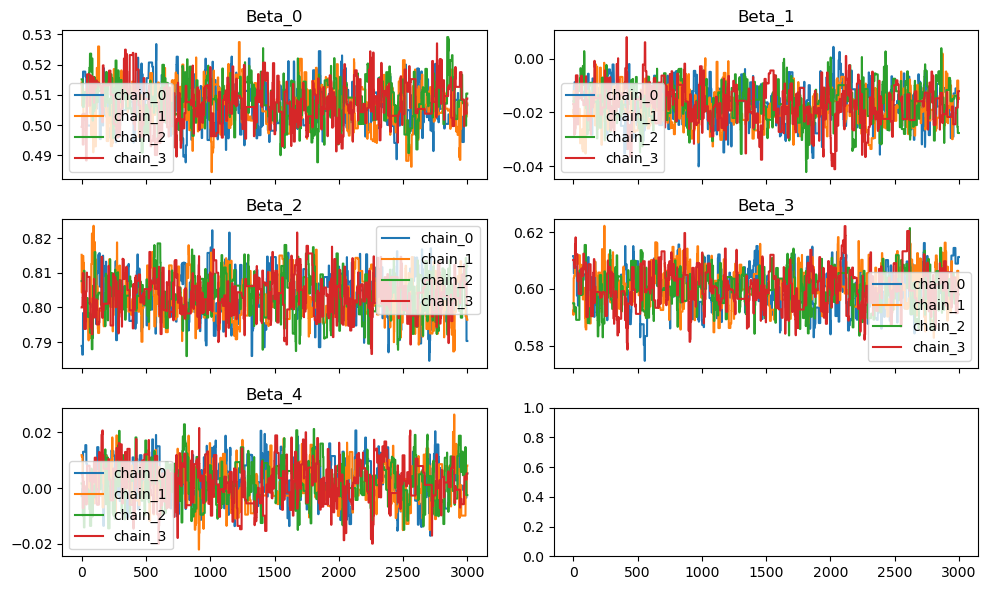

In [24]:
model.plot_beta_traces(figsize=(10, 6), layout=(3, 2))

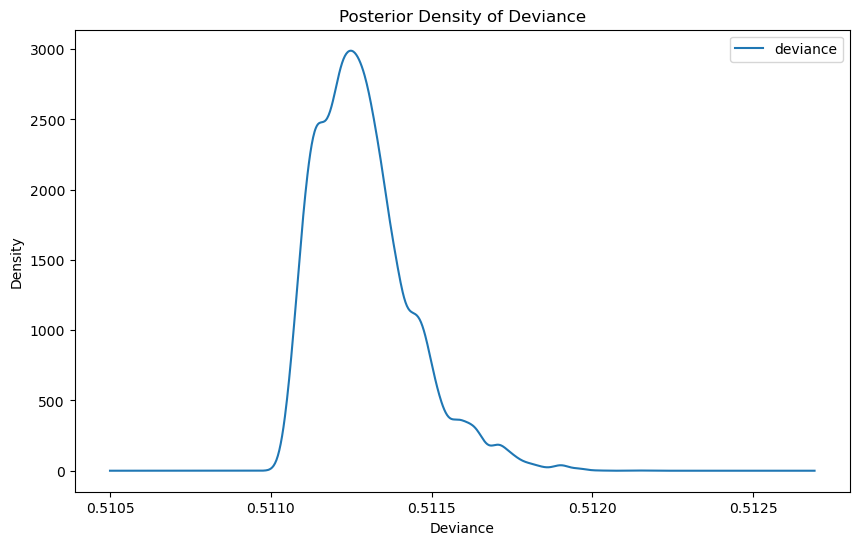

In [25]:
model.plot_deviance_density(X, y, figsize=(10, 6))

# **Regresión Gamma**

In [26]:
n = 2000

beta_0 = 0.5
beta_1 = 1.2
alpha_true = 3.5


x = torch.randn(n)


X = torch.stack([torch.ones(n), x], dim=1)


z = beta_0 + beta_1 * x
mu = torch.exp(z)


rate = alpha_true / mu

y = torch.distributions.Gamma(
    concentration=alpha_true,
    rate=rate
).sample()

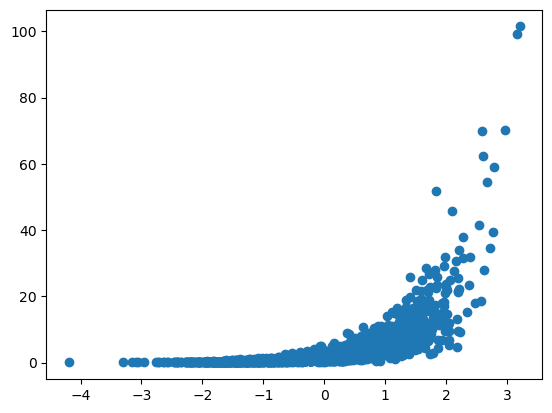

In [27]:
plt.scatter(X[:, 1], y)
plt.show()

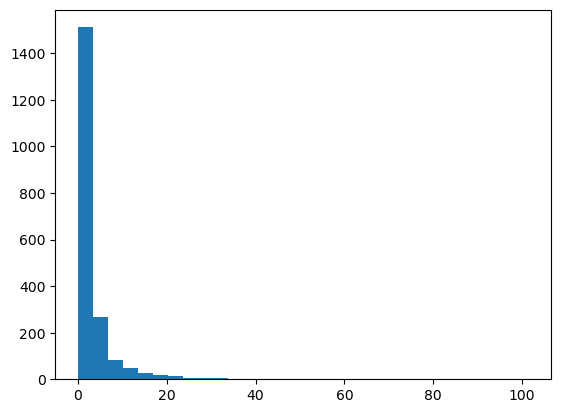

In [28]:
plt.hist(y, bins=30)
plt.show()

In [29]:
gamma_model = BayesianGammaRegression(X, y, a=10, b= 1)

In [30]:
gamma_model.fit(n_iter=8000, burn_in=2000, n_chains=4, step_size=0.05)

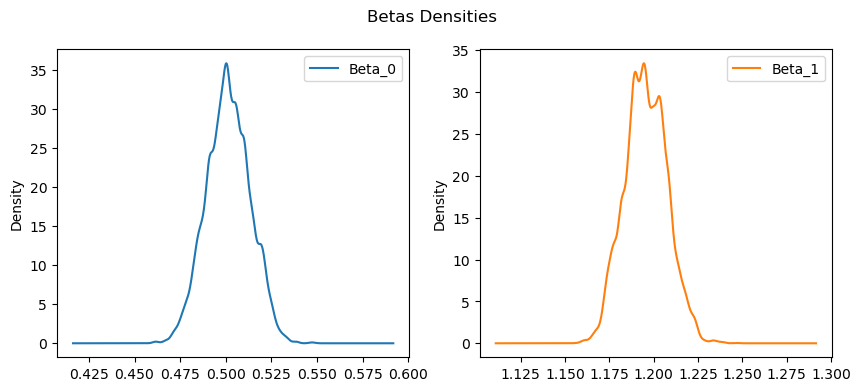

In [31]:
gamma_model.plot_betas_densities(layout=(1, 2), figsize=(10, 4))

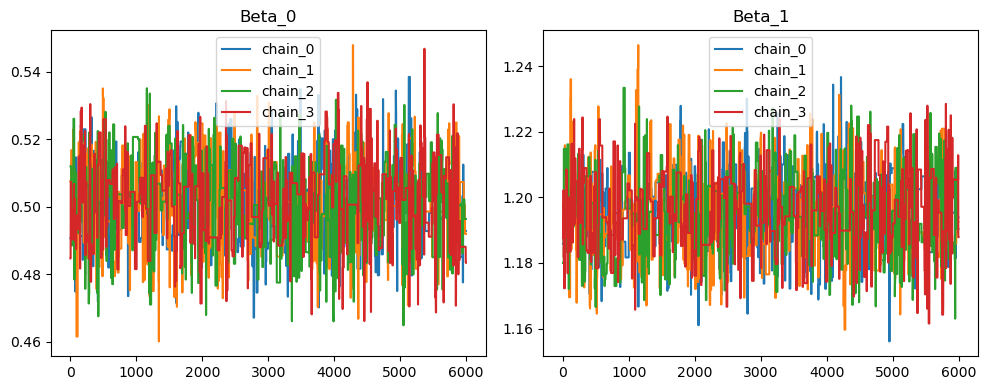

In [32]:
gamma_model.plot_beta_traces(figsize=(10, 4), layout=(1, 2))

# **Bayesian Neural Network**

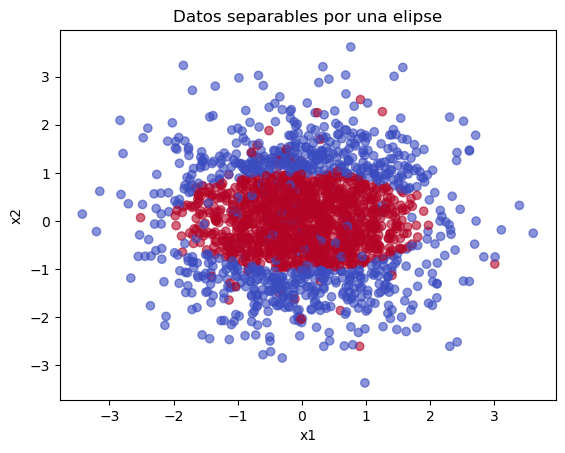

In [33]:
def generate_elliptical_data(n=500, a=2.0, b=1.0, noise=0.05):

    # Datos uniformes
    X = torch.randn(n, 2)

    # Escalamos para que haya puntos dentro y fuera


    # Ecuación de la elipse
    ellipse_val = (X[:, 0]**2) / a**2 + (X[:, 1]**2) / b**2

    # Etiquetas
    y = (ellipse_val <= 1).float()

    # Añadir ruido (flip de etiquetas)
    flip_mask = torch.rand(n) < noise
    y[flip_mask] = 1 - y[flip_mask]

    return X, y
    
# Generar datos
X, y = generate_elliptical_data(n=2000, a=2.0, b=1.0, noise=0.05)
# Visualización
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.6)
plt.title("Datos separables por una elipse")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [34]:
X_train, y_train = X[:1800, :], y[:1800]
X_test, y_test = X[1800:, :], y[1800:]

In [35]:
bnn_model = BayesianNeuralNetwork1Hidden(X_train, y_train, tau2=100, hidden_dim=5)

In [36]:
bnn_model.fit(8000, 4000, 3, 0.05)

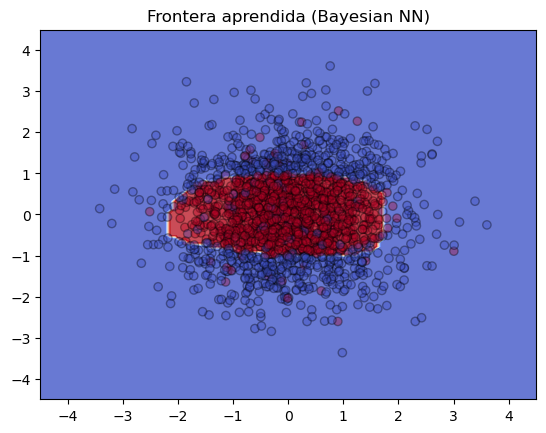

In [37]:
xx, yy = torch.meshgrid(
    torch.linspace(-4.5, 4.5, 100),
    torch.linspace(-4.5, 4.5, 100),
    indexing="ij"
)

grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

probs = bnn_model.predict_mean(grid)
probs = probs.reshape(100, 100).detach()

plt.contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.35)
plt.title("Frontera aprendida (Bayesian NN)")
plt.show()

In [38]:
bnn_model.accuracy_ci(X_train, y_train)

(tensor(0.8900), tensor(0.9306))

In [39]:
bnn_model.accuracy_ci(X_test, y_test)

(tensor(0.9000), tensor(0.9550))

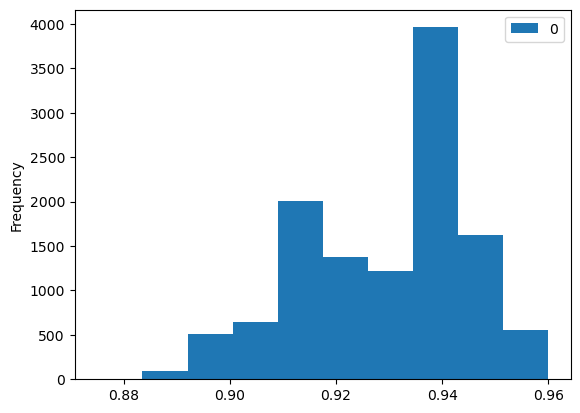

In [40]:
pd.DataFrame(bnn_model.accuracy_samples(X_test, y_test).reshape(-1)).plot.hist()
plt.show()

<Axes: ylabel='Frequency'>

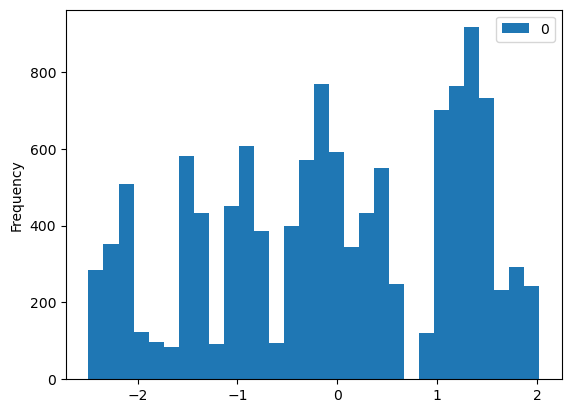

In [41]:
pd.DataFrame(bnn_model.W1_samples[:, :, 2].flatten()).plot.hist(bins=30)

<Axes: >

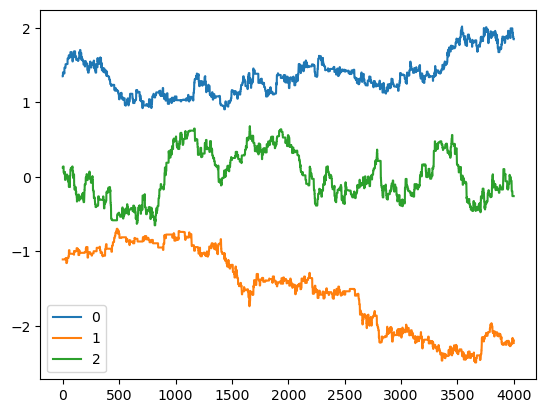

In [42]:
pd.DataFrame(bnn_model.W1_samples[:, :, 2]).plot()

In [43]:
bnn_model.W2_samples.mean(dim=(0, 1)).reshape(-1, 1)

tensor([[-0.3200],
        [ 3.4506],
        [-3.6490],
        [-0.4575],
        [ 1.1208]])

# **Bayesian Neural Network MALA**

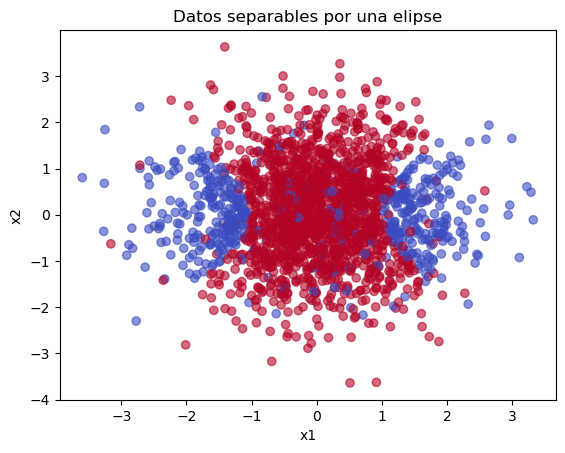

In [44]:
def generate_hyperbolic_data(n=500, a=2.0, b=1.0, noise=0.05):

    # Datos uniformes
    X = torch.randn(n, 2)



    hyperbolic_val = (X[:, 0]**2) / a**2 - (X[:, 1]**2) / b**2

    # Etiquetas
    y = (hyperbolic_val <= 1).float()

    # Añadir ruido (flip de etiquetas)
    flip_mask = torch.rand(n) < noise
    y[flip_mask] = 1 - y[flip_mask]

    return X, y

# Generar datos
X, y = generate_hyperbolic_data(n=2000, a=1.0, b=1.0, noise=0.05)
# Visualización
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.6)
plt.title("Datos separables por una elipse")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [45]:
X_train, y_train = X[:1800, :], y[:1800]
X_test, y_test = X[1800:, :], y[1800:]

In [60]:
bnn_model = BayesianNeuralNetwork1Hidden_MALA(X_train, y_train, activation=torch.relu, tau2=100.0)

In [61]:
bnn_model.fit(n_iter=10000, burn_in=7000, n_chains=4, step_size=0.001)

<Axes: >

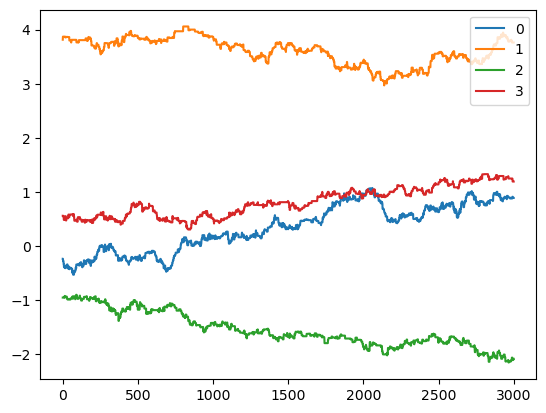

In [62]:
pd.DataFrame(bnn_model.W2_samples[:, :, 1]).plot()

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>]],
      dtype=object)

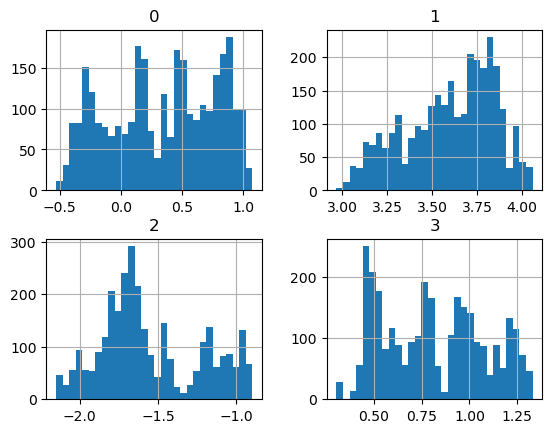

In [63]:
pd.DataFrame(bnn_model.W2_samples[:, :, 1]).hist(bins=30)

In [64]:
bnn_model.accuracy_ci(X_test, y_test)

(tensor(0.9350), tensor(0.9600))

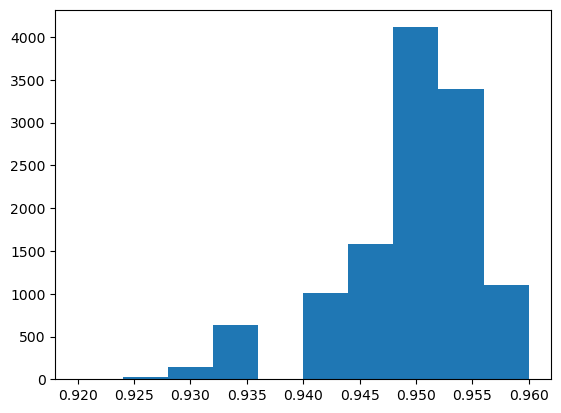

In [65]:
plt.hist(bnn_model.accuracy_samples(X_test, y_test).reshape(-1, 1))
plt.show()

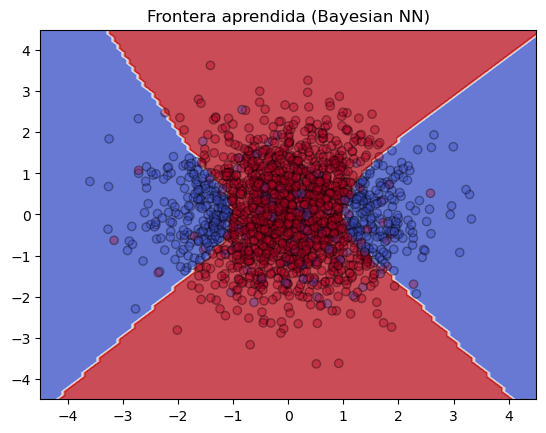

In [66]:
xx, yy = torch.meshgrid(
    torch.linspace(-4.5, 4.5, 100),
    torch.linspace(-4.5, 4.5, 100),
    indexing="ij"
)

grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

probs = bnn_model.predict_mean(grid)
probs = probs.reshape(100, 100).detach()

plt.contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.35)
plt.title("Frontera aprendida (Bayesian NN)")
plt.show()